# Day 08. Exercise 05
# Clustering

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [2]:
df = pd.read_csv('../data/regression.csv')
df.drop(columns=['pageviews', 'uid'], inplace=True)
df

,num_commits,AVG(diff)
0,62,-64.400000
1,20,-74.800000
2,61,-159.000000
3,51,-61.600000
4,5,-5.666667
5,118,-98.750000
6,65,-95.500000
7,79,-92.600000
8,60,-86.400000
9,18,-105.400000


## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [3]:
kmeans = KMeans(n_clusters=3, random_state=21)
kmeans.fit(df)
labels = kmeans.labels_
labels

c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 0, 1, 0, 0, 2, 2, 2, 2, 1, 1, 0, 2, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 2, 1, 0, 1, 1])

Text(0.5, 1.0, 'KMeans')

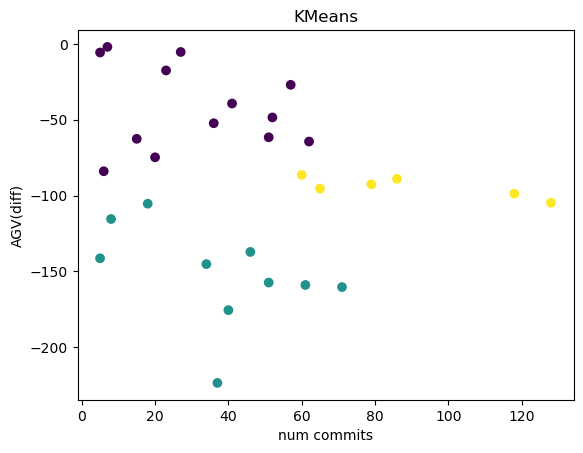

In [4]:
plt.scatter(df.num_commits, df['AVG(diff)'], c=labels)
plt.xlabel('num commits')
plt.ylabel('AGV(diff)')
plt.title('KMeans')

In [5]:
silhouette_score(df, labels)

0.4454402135233297

## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [6]:
dbscan_model = DBSCAN(eps=20, min_samples=2)
dbscan_model.fit(df)
dbscan_labels = dbscan_model.labels_
dbscan_labels

array([ 0,  1,  2,  0,  3,  4,  5,  5,  5,  6,  7,  3,  5,  0,  8,  0,  7,
       -1, -1,  1, -1,  0,  8,  2,  4, -1,  1,  6,  2], dtype=int64)

Text(0.5, 1.0, 'DBSCAN')

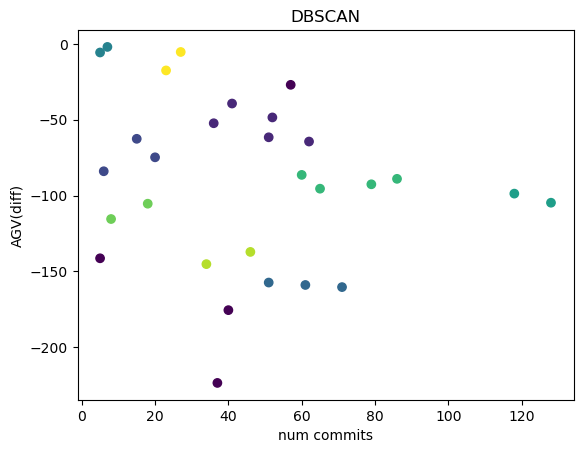

In [7]:
plt.scatter(df.num_commits, df['AVG(diff)'], c=dbscan_labels)
plt.xlabel('num commits')
plt.ylabel('AGV(diff)')
plt.title('DBSCAN')

In [8]:
silhouette_score(df, dbscan_labels)

0.38339641455696616

## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

In [9]:
ag_model = AgglomerativeClustering(n_clusters=5)
ag_model.fit(df)
ag_labels = ag_model.labels_
ag_labels

array([2, 3, 0, 2, 4, 1, 1, 1, 1, 3, 0, 4, 1, 2, 4, 2, 0, 2, 3, 3, 0, 2,
       4, 0, 1, 0, 3, 3, 0], dtype=int64)

Text(0.5, 1.0, 'Agglomerative Clustering')

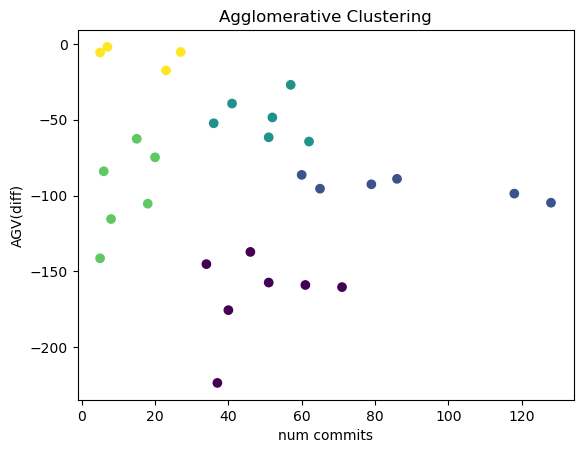

In [10]:
plt.scatter(df.num_commits, df['AVG(diff)'], c=ag_labels)
plt.xlabel('num commits')
plt.ylabel('AGV(diff)')
plt.title('Agglomerative Clustering')

In [11]:
silhouette_score(df, ag_labels)

0.46383015199381467

Text(0, 0.5, 'Euclidean Distance')

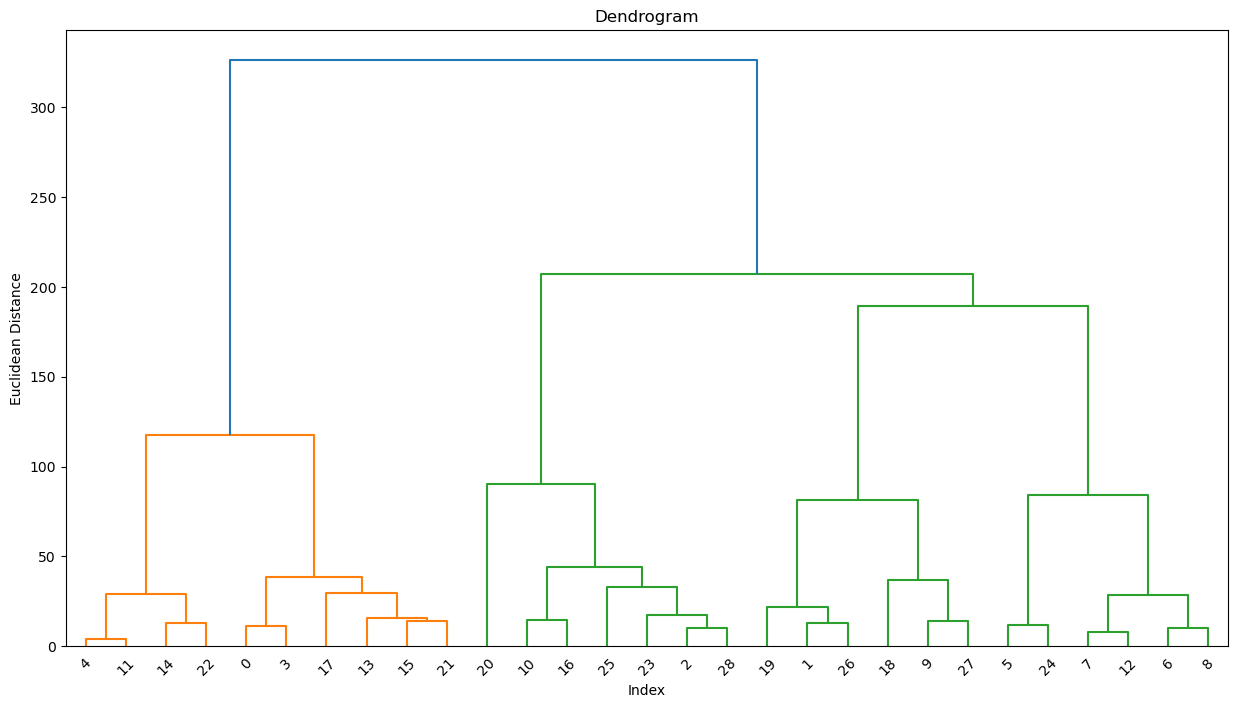

In [12]:
Z = linkage(df, method='ward')

plt.figure(figsize=(15,8))
dendrogram(Z)
plt.title('Dendrogram')
plt.xlabel('Index')
plt.ylabel('Euclidean Distance')

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [13]:
def optimaze_cluster_param(clustering_model_class, params, opt_param_name, param_range):
    silhouette_score_arr = []
    best_param_value = None
    best_score = -1

    for opt_param_value in param_range:
        params[opt_param_name] = opt_param_value
        model = clustering_model_class(**params)
        clusters = model.fit_predict(df)
        score = silhouette_score(df, clusters)
        silhouette_score_arr.append(score)

        if score > best_score:
            best_score = score
            best_param_value = opt_param_value

    fig, ax = plt.subplots(1, 2, figsize=(15, 8))
    
    ax[0].plot(param_range, silhouette_score_arr, marker='o')
    ax[0].set_title(f'Silhouette score x {opt_param_name}')
    ax[0].set_xlabel(opt_param_name)
    ax[0].set_ylabel('Silhouette score')

    params[opt_param_name] = best_param_value
    model = clustering_model_class(**params)
    clusters = model.fit_predict(df)

    ax[1].scatter(df.num_commits, df['AVG(diff)'], c=clusters)
    ax[1].set_title(f'Clustering with {opt_param_name} = {best_param_value}')
    ax[1].set_xlabel('Num of commits')
    ax[1].set_ylabel('AVG diierences')

    return best_score, best_param_value

c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

(0.48638087320227846, 8)

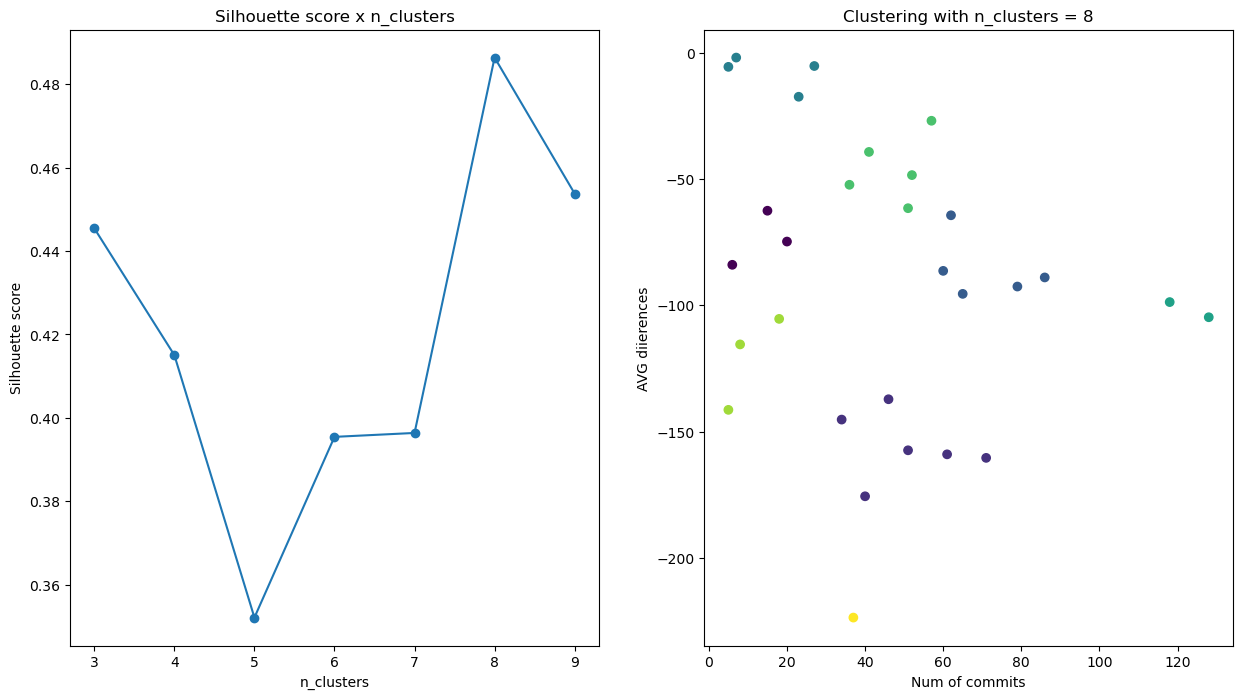

In [14]:
params_kmeans = {'random_state': 21}
optimaze_cluster_param(KMeans, params_kmeans, 'n_clusters', range(3, 10))

(0.4794129092034348, 22)

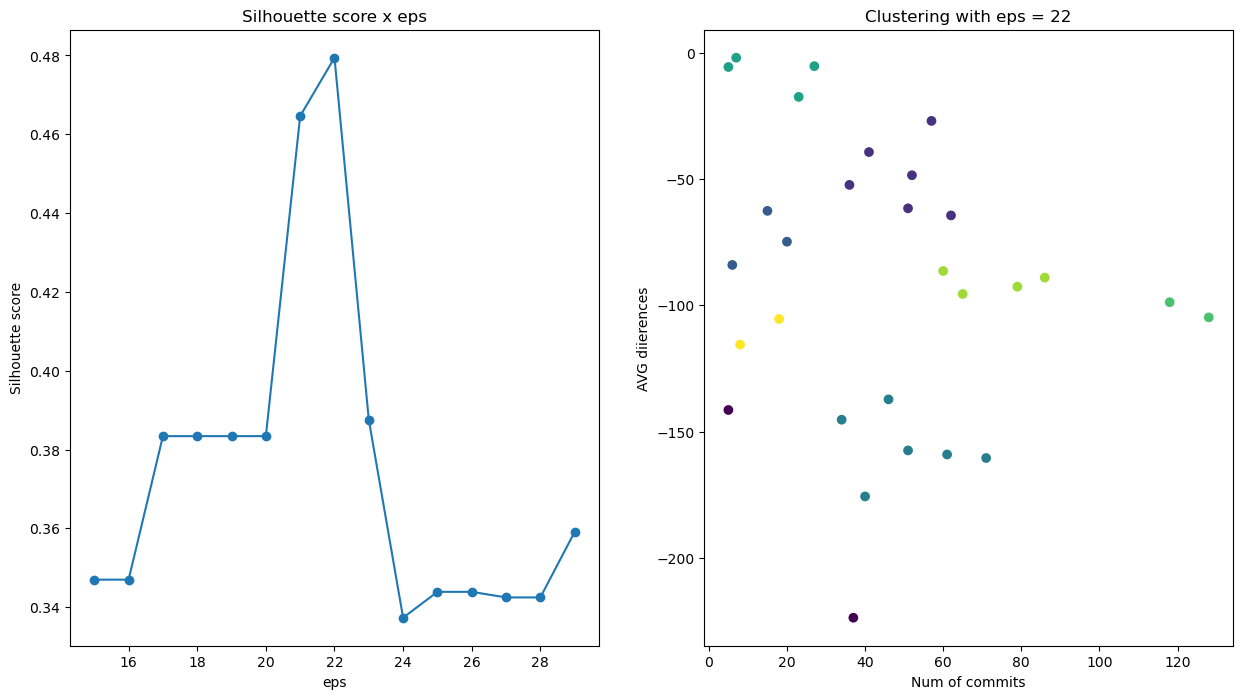

In [15]:
optimaze_cluster_param(DBSCAN, {'min_samples':2}, 'eps', range(15,30))

(0.48713041554757475, 1)

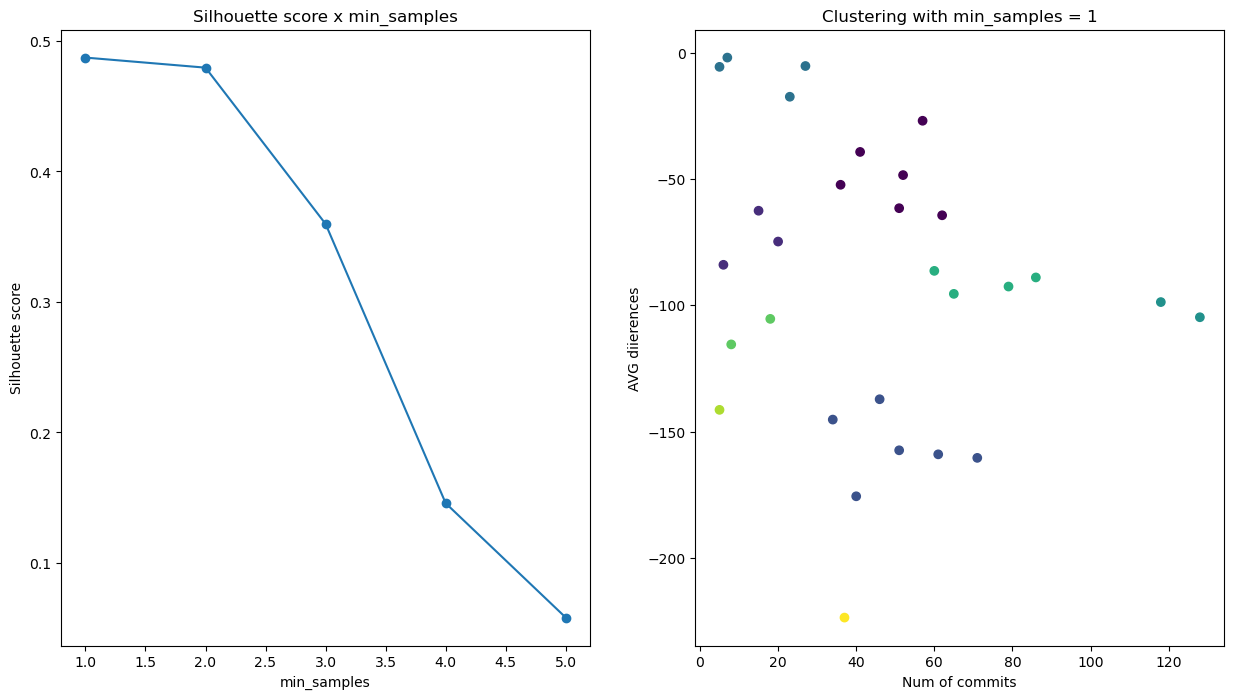

In [16]:
optimaze_cluster_param(DBSCAN, {'eps':22}, 'min_samples', range(1,6))

(0.50779855565622, 8)

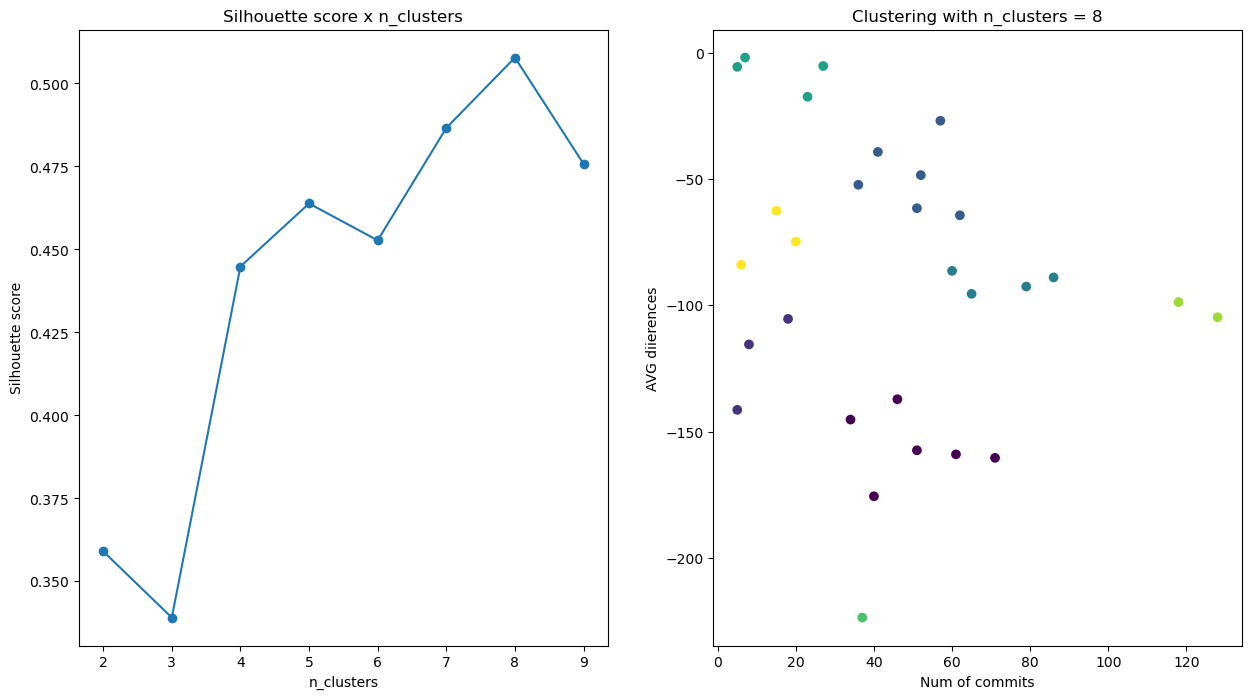

In [17]:
optimaze_cluster_param(AgglomerativeClustering, {}, 'n_clusters', range(2, 10))